# 03 — Generación de variables aleatorias

Pista B de [`estructura-proyecto.md`](../estructura-proyecto.md): las fuentes
de aleatoriedad de §4, los tres pares de métodos de §7 y la validación de §8.

No toca OSRM ni la red vial. Todo sale de la clase `Generador` de
[`src/generadores.py`](../src/generadores.py), que es lo que la pista C importa.

Tres preguntas:

1. ¿Los generadores producen la distribución que dicen? (§8)
2. De los dos métodos para normales, ¿cuál conviene? (§7, par 1)
3. ¿Por qué validar un generador en vez de confiar en él?

## 0. Configuración

In [1]:
import json
import sys
import timeit
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from scipy.integrate import quad

sys.path.insert(0, str(Path.cwd().parent / "src"))

import config
import generadores as gen

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 170)

# Paleta única del proyecto (§14). Nadie elige colores por su cuenta.
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.prop_cycle": plt.cycler(color=config.PALETA),
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 9,
})

N = 1_000_000          # tamaño de muestra de las pruebas de §8
N_TIEMPO = 1_000_000   # tamaño del banco de tiempos (§7, criterio 1)
REPETICIONES = 7       # repeticiones de timeit; se reporta la mediana

print(f"semilla global : {config.SEMILLA:,}")
print(f"muestra        : {N:,}")
print(f"fuentes        : {gen.FUENTES}")
print(f"métodos normal : {gen.METODOS_NORMAL}")

semilla global : 20,172,026
muestra        : 1,000,000
fuentes        : ('pcg64', 'lcg', 'randu')
métodos normal : ('polar', 'rechazo')


## 1. Las tres fuentes de uniformes

Par 3 de §7. Los tres dan uniformes en [0, 1):

| Fuente | Recurrencia | Papel |
|---|---|---|
| `lcg` | `x = (1664525·x + 1013904223) mod 2³²` | el generador propio |
| `randu` | `x = 65539·x mod 2³¹` | control negativo |
| `pcg64` | el de NumPy | referencia |

RANDU está a propósito: sirve para mostrar que un generador puede pasar las
pruebas de una dimensión y aun así estar roto.

In [2]:
# El LCG genera por bloques con salto adelante. La sucesión tiene que salir
# idéntica a la del bucle ingenuo; si no, todo lo demás sobra.
for nombre, (a, c, m) in {
    "lcg":   (config.LCG_A, config.LCG_C, config.LCG_M),
    "randu": (config.RANDU_A, config.RANDU_C, config.RANDU_M),
}.items():
    f = gen.FuenteLCG(config.SEMILLA, a, c, m, nombre)
    x0 = f.semilla
    vectorizado = f.enteros(20_000)

    ingenuo, x = np.empty(20_000, dtype=np.uint64), x0
    for i in range(20_000):
        x = (a * x + c) % m
        ingenuo[i] = x

    assert np.array_equal(vectorizado, ingenuo), f"{nombre}: el salto adelante no reproduce la sucesión"
    print(f"{nombre:6s}  salto adelante == bucle ingenuo sobre 20 000 valores  ✓")

# Y la sucesión no debe depender de cómo se parta en llamadas.
f1 = gen.FuenteLCG(config.SEMILLA, config.LCG_A, config.LCG_C, config.LCG_M)
troceado = np.concatenate([f1.enteros(1_000), f1.enteros(7_000), f1.enteros(5)])
f2 = gen.FuenteLCG(config.SEMILLA, config.LCG_A, config.LCG_C, config.LCG_M)
assert np.array_equal(troceado, f2.enteros(8_005))
print("        la sucesión no depende de cómo se parta en llamadas          ✓")

lcg     salto adelante == bucle ingenuo sobre 20 000 valores  ✓
randu   salto adelante == bucle ingenuo sobre 20 000 valores  ✓
        la sucesión no depende de cómo se parta en llamadas          ✓


In [3]:
U = {}
for nombre in gen.FUENTES:
    g = gen.Generador(config.SEMILLA, nombre)
    U[nombre] = g.uniformes(N)

pd.DataFrame([
    {"fuente": k, "n": v.size, "media": v.mean(), "varianza": v.var(),
     "mín": v.min(), "máx": v.max()}
    for k, v in U.items()
]).round(6)

,fuente,n,media,varianza,mín,máx
0,pcg64,1000000,0.499668,0.083330,0.000001,1.000000
1,lcg,1000000,0.500395,0.083353,0.000001,1.000000
2,randu,1000000,0.500315,0.083280,0.000002,0.999999


Los tres tienen media ≈ 0.5 y varianza ≈ 1/12. Hasta aquí son indistinguibles.

## 2. Validación de los uniformes — §8

Cinco pruebas. Las dos primeras miran la distribución marginal; las tres
últimas, el orden, que es donde un LCG se rompe.

| Prueba | Qué detecta |
|---|---|
| Kolmogórov–Smirnov | desviación de U(0,1) |
| Chi-cuadrado, 100 clases | lo mismo, por conteo en celdas |
| Rachas ascendentes/descendentes | tendencias |
| Prueba del hueco | espaciado entre caídas en (0, 0.5) |
| Autocorrelación, rezagos 1–20 | dependencia a corta distancia |

In [4]:
filas = []
for nombre, u in U.items():
    ks = stats.kstest(u, "uniform")
    obs = np.histogram(u, bins=100, range=(0, 1))[0]
    chi = stats.chisquare(obs)
    rac = gen.prueba_rachas(u)
    hue = gen.prueba_hueco(u)
    aut = gen.autocorrelacion(u, 20)
    filas.append({
        "fuente": nombre,
        "KS D": ks.statistic, "KS p": ks.pvalue,
        "χ² (99 gl)": chi.statistic, "χ² p": chi.pvalue,
        "rachas z": rac["z"], "rachas p": rac["p"],
        "hueco χ²": hue["chi2"], "hueco p": hue["p"],
        "|r| máx": np.abs(aut["r"]).max(), "rezagos fuera de banda": aut["fuera"],
    })

pruebas_unif = pd.DataFrame(filas).set_index("fuente")
display(pruebas_unif.round(4))

print(f"\nBanda del 95 % para la autocorrelación con n = {N:,}: ±{1.96/np.sqrt(N):.5f}")
print("\nNingún valor p bajo 'prueba' que el generador sea bueno: solo dice que")
print("no hay evidencia para rechazarlo al nivel elegido.")

,KS D,KS p,χ² (99 gl),χ² p,rachas z,rachas p,hueco χ²,hueco p,|r| máx,rezagos fuera de banda
fuente,,,,,,,,,,
pcg64,0.0009,0.3351,91.6000,0.6886,0.3621,0.7173,10.1497,0.4275,0.0026,1
lcg,0.0008,0.5608,71.6558,0.9825,0.1036,0.9175,9.2928,0.5046,0.0018,0
randu,0.0012,0.1002,103.8438,0.3498,1.3155,0.1883,4.1095,0.9423,0.0023,1



Banda del 95 % para la autocorrelación con n = 1,000,000: ±0.00196

Ningún valor p bajo 'prueba' que el generador sea bueno: solo dice que
no hay evidencia para rechazarlo al nivel elegido.


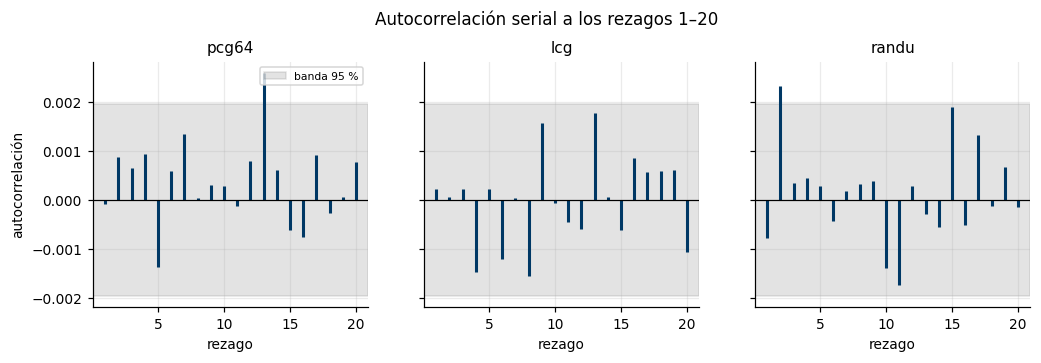

In [5]:
fig, ejes = plt.subplots(1, 3, figsize=(11, 2.9), sharey=True)
for eje, (nombre, u) in zip(ejes, U.items()):
    r = gen.autocorrelacion(u, 20)
    eje.axhspan(-r["banda95"], r["banda95"], color=config.GREY, alpha=0.18,
                label="banda 95 %")
    eje.vlines(np.arange(1, 21), 0, r["r"], color=config.NAVY, lw=2)
    eje.axhline(0, color="k", lw=0.8)
    eje.set_title(nombre, fontsize=10)
    eje.set_xlabel("rezago")
ejes[0].set_ylabel("autocorrelación")
ejes[0].legend(fontsize=7, loc="upper right")
fig.suptitle("Autocorrelación serial a los rezagos 1–20", y=1.04, fontsize=11)
plt.show()

**Los tres pasan, incluido RANDU.** Ninguna prueba de una dimensión lo delata:
sus marginales y su orden a corta distancia son correctos.

## 3. RANDU: por qué no basta con validar en una dimensión

RANDU usa `a = 65539 = 2¹⁶ + 3`. Elevando al cuadrado:

$$a^2 = 2^{32} + 6\cdot 2^{16} + 9 \equiv 6a - 9 \pmod{2^{31}}$$

de donde sale una recurrencia **exacta** entre tres valores consecutivos:

$$x_{n+2} = 6x_{n+1} - 9x_n \pmod{2^{31}}
\quad\Longrightarrow\quad
9u_n - 6u_{n+1} + u_{n+2} \in \mathbb{Z}$$

O sea que todas las tripletas caen sobre planos paralelos, y como
$9u_1 - 6u_2 + u_3$ vive en $(-6, 10)$, son 15. Al ser una identidad algebraica
se verifica con aritmética entera, no con estadística.

In [6]:
# La identidad, en enteros exactos: el residuo tiene que ser 0 y nada más.
r = gen.FuenteLCG(config.SEMILLA, config.RANDU_A, config.RANDU_C, config.RANDU_M)
x = r.enteros(60_000).astype(object)   # object = enteros de Python, sin desbordes
residuos = set(((9 * x[:-2] - 6 * x[1:-1] + x[2:]) % config.RANDU_M).tolist())
assert residuos == {0}, f"la identidad de RANDU no se cumple: {residuos}"
print(f"9·x[n] − 6·x[n+1] + x[n+2] mod 2³¹  ->  residuos observados: {residuos}   ✓")

# Y en uniformes: la combinación cae sobre enteros, o sea sobre 15 planos.
def combinacion(u):
    return 9 * u[:-2] - 6 * u[1:-1] + u[2:]

for nombre in ("randu", "pcg64"):
    c = combinacion(U[nombre][:200_000])
    dist = np.abs(c - np.round(c))          # distancia al entero más cercano
    coplanar = dist.max() < 1e-9
    veredicto = (f"cae sobre {len(np.unique(np.round(c).astype(int)))} planos exactos"
                 if coplanar else "no cae sobre planos: la combinación es continua")
    print(f"{nombre:6s}  distancia media al entero más cercano = {dist.mean():.3e}   ->  {veredicto}")

c = combinacion(U["randu"])
assert np.abs(c - np.round(c)).max() < 1e-9, "las tripletas de RANDU no son coplanares"
assert len(np.unique(np.round(c).astype(int))) == 15
print("\nRANDU: 15 planos exactos. PCG64: distancia ~0.25, o sea ninguna estructura.")

9·x[n] − 6·x[n+1] + x[n+2] mod 2³¹  ->  residuos observados: {0}   ✓
randu   distancia media al entero más cercano = 0.000e+00   ->  cae sobre 15 planos exactos
pcg64   distancia media al entero más cercano = 2.497e-01   ->  no cae sobre planos: la combinación es continua

RANDU: 15 planos exactos. PCG64: distancia ~0.25, o sea ninguna estructura.


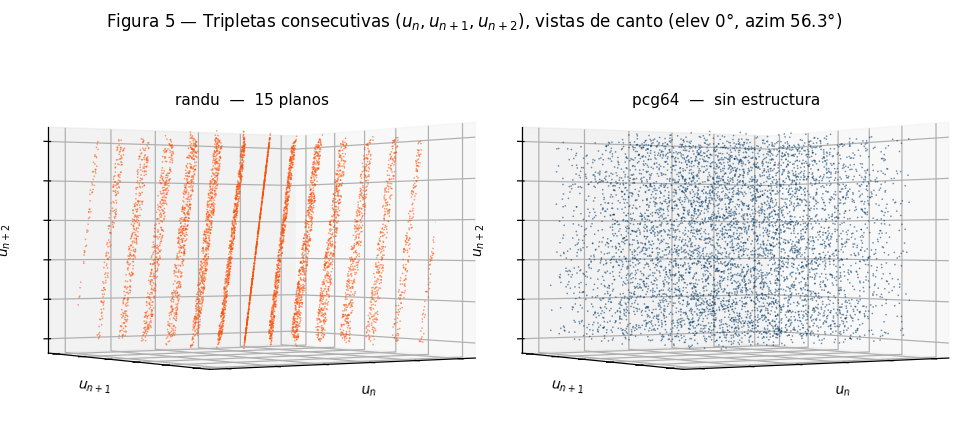

guardada: C:\Users\Virus\OneDrive - UVG\Progra\proyecto-trafico\figuras\05_randu_planos.png


In [7]:
# ---- Figura 5 de §14: las tripletas de RANDU vistas de canto ----
# Los planos tienen normal (9, −6, 1) y para verlos de canto hay que mirar en
# una dirección perpendicular a ella: elevación 0 y azimut arctan(9/6) = 56.31°.
AZIMUT = np.degrees(np.arctan2(9.0, 6.0))
assert abs(9 * np.cos(np.radians(AZIMUT)) - 6 * np.sin(np.radians(AZIMUT))) < 1e-9

fig = plt.figure(figsize=(11, 3.8))
for k, (nombre, color) in enumerate([("randu", config.ORANGE), ("pcg64", config.NAVY)]):
    u = U[nombre][:6000]
    eje = fig.add_subplot(1, 2, k + 1, projection="3d")
    eje.scatter(u[:-2], u[1:-1], u[2:], s=1.2, c=color, alpha=0.55, linewidths=0)
    eje.view_init(elev=0, azim=AZIMUT)
    eje.set_box_aspect(None, zoom=1.30)     # llena el hueco que dejan los ejes 3D
    eje.set_xlabel("$u_n$", labelpad=-8); eje.set_ylabel("$u_{n+1}$", labelpad=-8)
    eje.set_zlabel("$u_{n+2}$", labelpad=-8)
    eje.set_xticklabels([]); eje.set_yticklabels([]); eje.set_zticklabels([])
    eje.set_title(f"{nombre}" + ("  —  15 planos" if nombre == "randu" else "  —  sin estructura"),
                  fontsize=10, y=0.93)
fig.suptitle("Figura 5 — Tripletas consecutivas $(u_n, u_{n+1}, u_{n+2})$, "
             f"vistas de canto (elev 0°, azim {AZIMUT:.1f}°)", y=1.02, fontsize=11)
fig.subplots_adjust(top=0.90, bottom=0.02, wspace=0.02)
for ext in ("png", "pdf"):
    fig.savefig(config.FIGURAS / f"05_randu_planos.{ext}")
plt.show()
print(f"guardada: {config.FIGURAS / '05_randu_planos.png'}")

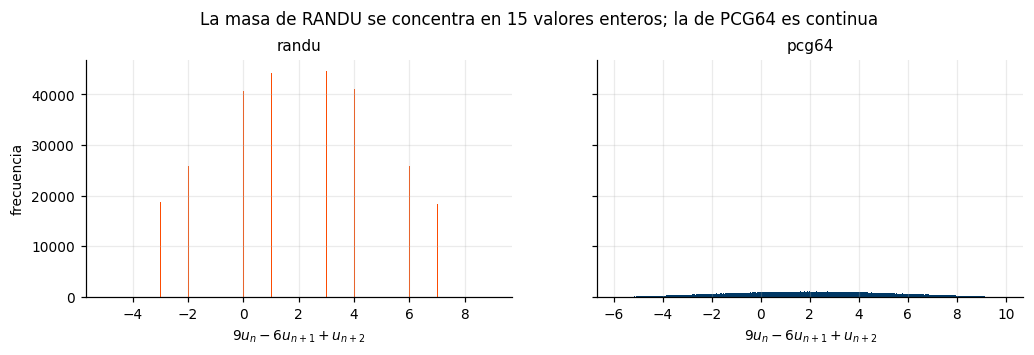

In [8]:
# La misma evidencia, cuantitativa: el histograma de la combinación lineal.
fig, ejes = plt.subplots(1, 2, figsize=(11, 2.8), sharey=True)
for eje, (nombre, color) in zip(ejes, [("randu", config.ORANGE), ("pcg64", config.NAVY)]):
    eje.hist(combinacion(U[nombre][:400_000]), bins=700, color=color)
    eje.set_title(f"{nombre}", fontsize=10)
    eje.set_xlabel("$9u_n - 6u_{n+1} + u_{n+2}$")
ejes[0].set_ylabel("frecuencia")
fig.suptitle("La masa de RANDU se concentra en 15 valores enteros; la de PCG64 es continua",
             y=1.04, fontsize=11)
plt.show()

Esto es lo que justifica §8: RANDU pasó las cinco pruebas de la sección 2 y
está roto igual. Los defectos que importan no se ven en una dimensión.

Queda por saber si esa estructura mueve el Δ% del proyecto, que es el criterio 5
y lo corre el notebook 04.

## 4. Normales: polar contra aceptación-rechazo

Par 1 de §7, el principal, porque alimenta la fuente D.

**Polar (Marsaglia).** Se sortean $V_1, V_2 \sim U(-1,1)$ hasta caer dentro del
círculo unitario ($S = V_1^2+V_2^2 \le 1$, probabilidad $\pi/4$) y se devuelven
dos normales $V_i\sqrt{-2\ln S/S}$. Sin senos ni cosenos.

**Rechazo con envolvente exponencial** (Ross, ejemplo 5f). Se genera $|Z|$ con
$g(x)=e^{-x}$ y cota $c=\sqrt{2e/\pi}\approx 1.3155$ (aceptación $\approx 0.760$).
La condición se reduce a $U \le e^{-(Y-1)^2/2}$ y el signo cuesta un uniforme más.

In [9]:
Z = {}
consumo = {}
for metodo in gen.METODOS_NORMAL:
    g = gen.Generador(config.SEMILLA, "pcg64", metodo)
    Z[metodo] = g.normales(N)
    consumo[metodo] = g.uniformes_consumidos / N

filas = []
for metodo, z in Z.items():
    ks = stats.kstest(z, "norm")
    filas.append({
        "método": metodo,
        "media": z.mean(), "desv.": z.std(ddof=1),
        "asimetría": stats.skew(z), "curtosis exc.": stats.kurtosis(z),
        "KS D": ks.statistic, "KS p": ks.pvalue,
    })
normales_res = pd.DataFrame(filas).set_index("método")
display(normales_res.round(5))
print("Momentos teóricos de la normal estándar: media 0, desv. 1, asimetría 0, curtosis exc. 0")

for metodo, z in Z.items():
    assert abs(z.mean()) < 0.01, metodo
    assert abs(z.std(ddof=1) - 1) < 0.01, metodo
    assert stats.kstest(z, "norm").pvalue > 0.01, f"{metodo}: KS rechaza la normalidad"
print("\nMomentos y KS dentro de tolerancia para ambos métodos  ✓")

,media,desv.,asimetría,curtosis exc.,KS D,KS p
método,,,,,,
polar,0.00011,1.00032,0.00259,0.00489,0.00059,0.87858
rechazo,0.00042,0.99920,-0.00043,0.00083,0.00082,0.51366


Momentos teóricos de la normal estándar: media 0, desv. 1, asimetría 0, curtosis exc. 0



Momentos y KS dentro de tolerancia para ambos métodos  ✓


In [10]:
# Shapiro-Wilk no admite más de 5 000 observaciones, de ahí las submuestras de
# §8. Si las normales son buenas, los 40 valores p salen uniformes en [0,1].
rng_sub = np.random.default_rng(config.SEMILLA)
filas = []
for metodo, z in Z.items():
    ps = [stats.shapiro(rng_sub.choice(z, 5000, replace=False)).pvalue for _ in range(40)]
    ps = np.array(ps)
    filas.append({"método": metodo, "submuestras": len(ps),
                  "p mediano": np.median(ps), "p mínimo": ps.min(),
                  "rechazos al 5 %": int((ps < 0.05).sum()),
                  "KS de los p vs U(0,1)": stats.kstest(ps, "uniform").pvalue})
display(pd.DataFrame(filas).set_index("método").round(4))
print("Se esperan ~2 rechazos de 40 al nivel del 5 % aunque el generador sea perfecto.")

,submuestras,p mediano,p mínimo,rechazos al 5 %,"KS de los p vs U(0,1)"
método,,,,,
polar,40,0.3656,0.0285,2,0.0327
rechazo,40,0.4024,0.0526,0,0.4893


Se esperan ~2 rechazos de 40 al nivel del 5 % aunque el generador sea perfecto.


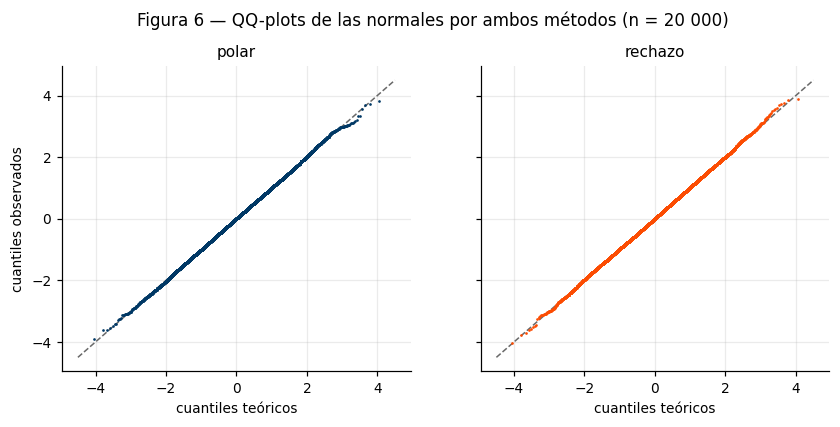

guardada: C:\Users\Virus\OneDrive - UVG\Progra\proyecto-trafico\figuras\06_qq_normales.png


In [11]:
# ---- Figura 6 de §14: QQ-plots ----
fig, ejes = plt.subplots(1, 2, figsize=(9, 3.6), sharex=True, sharey=True)
for eje, (metodo, color) in zip(ejes, [("polar", config.NAVY), ("rechazo", config.ORANGE)]):
    z = np.sort(Z[metodo][:20_000])
    teo = stats.norm.ppf((np.arange(z.size) + 0.5) / z.size)
    eje.plot([-4.5, 4.5], [-4.5, 4.5], color=config.GREY, lw=1, ls="--")
    eje.plot(teo, z, ".", ms=1.5, color=color)
    eje.set_title(f"{metodo}", fontsize=10)
    eje.set_xlabel("cuantiles teóricos")
ejes[0].set_ylabel("cuantiles observados")
fig.suptitle("Figura 6 — QQ-plots de las normales por ambos métodos (n = 20 000)",
             y=1.02, fontsize=11)
for ext in ("png", "pdf"):
    fig.savefig(config.FIGURAS / f"06_qq_normales.{ext}")
plt.show()
print(f"guardada: {config.FIGURAS / '06_qq_normales.png'}")

### Criterio 4 — comportamiento en la cola

$\Delta\%_{95}$ es una métrica de cola, así que un generador con pocas normales
extremas sesgaría justo el resultado que se reporta. El KS no lo detectaría:
mira el centro de la distribución, no los extremos.

In [12]:
filas = []
for metodo, z in Z.items():
    for s in (2.0, 3.0, 4.0):
        r = gen.razon_cola(z, s)
        filas.append({"método": metodo, "umbral": f"{s:.0f}σ",
                      "casos": r["casos"], "empírica": r["empirica"],
                      "teórica": r["teorica"], "razón emp./teó.": r["razon"]})
cola = pd.DataFrame(filas).set_index(["método", "umbral"])
display(cola.round(6))

for metodo, z in Z.items():
    assert 0.9 < gen.razon_cola(z, 3.0)["razon"] < 1.1, f"{metodo}: cola a 3σ fuera de rango"
print("Ambos métodos reproducen la cola a 3σ dentro del ±10 %  ✓")

casos  empírica   teórica  razón emp./teó.
método  umbral                                            
polar   2σ      45715  0.045715  0.045500         1.004719
        3σ       2673  0.002673  0.002700         0.990075
        4σ         68  0.000068  0.000063         1.073529
rechazo 2σ      45292  0.045292  0.045500         0.995423
        3σ       2624  0.002624  0.002700         0.971925
        4σ         62  0.000062  0.000063         0.978806

Ambos métodos reproducen la cola a 3σ dentro del ±10 %  ✓


## 5. Fuente D — velocidad del conductor

Lognormal de mediana 1.0 ($\mu = 0$) y $\sigma = 0.20$, exponenciando la normal.
Positiva por construcción y con cola a la derecha: hay conductores bastante más
lentos que el promedio, pero nadie va al triple.

σ = 0.2   mediana = 0.9999 (teórica 1.0000)
media = 1.0202 (teórica 1.0202)
KS D = 0.00059   p = 0.879

percentiles del multiplicador de velocidad:
  p5=0.720  p25=0.874  p50=1.000  p75=1.144  p95=1.391
  -> el 90 % central conduce entre 0.72× y 1.39× la velocidad de flujo libre


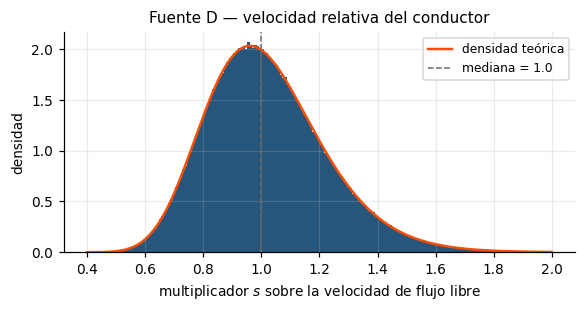

In [13]:
g = gen.Generador(config.SEMILLA)
s = g.lognormales(N, config.LOGN_MU, config.LOGN_SIGMA)
ks = stats.kstest(s, "lognorm", args=(config.LOGN_SIGMA, 0, np.exp(config.LOGN_MU)))

q = np.percentile(s, [5, 25, 50, 75, 95])
print(f"σ = {config.LOGN_SIGMA}   mediana = {np.median(s):.4f} (teórica {np.exp(config.LOGN_MU):.4f})")
print(f"media = {s.mean():.4f} (teórica {np.exp(config.LOGN_MU + config.LOGN_SIGMA**2/2):.4f})")
print(f"KS D = {ks.statistic:.5f}   p = {ks.pvalue:.3f}")
print(f"\npercentiles del multiplicador de velocidad:")
print(f"  p5={q[0]:.3f}  p25={q[1]:.3f}  p50={q[2]:.3f}  p75={q[3]:.3f}  p95={q[4]:.3f}")
print(f"  -> el 90 % central conduce entre {q[0]:.2f}× y {q[4]:.2f}× la velocidad de flujo libre")
assert abs(np.median(s) - 1.0) < 0.005
assert ks.pvalue > 0.01

fig, eje = plt.subplots(figsize=(6, 2.6))
eje.hist(s, bins=200, range=(0.4, 2.0), color=config.NAVY, alpha=0.85, density=True)
xs = np.linspace(0.4, 2.0, 400)
eje.plot(xs, stats.lognorm.pdf(xs, config.LOGN_SIGMA, 0, np.exp(config.LOGN_MU)),
         color=config.ORANGE, lw=1.6, label="densidad teórica")
eje.axvline(1.0, color=config.GREY, ls="--", lw=1, label="mediana = 1.0")
eje.set_xlabel("multiplicador $s$ sobre la velocidad de flujo libre")
eje.set_ylabel("densidad"); eje.legend(fontsize=8)
eje.set_title("Fuente D — velocidad relativa del conductor", fontsize=10)
plt.show()

## 6. Fuentes A y E — exponencial y Erlang

La exponencial va por transformada inversa, con un detalle: se usa
$-\ln(1-U)/\lambda$ en vez de $-\ln(U)/\lambda$ porque el LCG sí puede devolver
un 0 exacto y $-\ln 0$ es infinito. Con PCG64 el error tardaría millones de
corridas en aparecer.

La Erlang(k=2) es la convolución de dos exponenciales: espera de semáforo más
despeje de cola. Su densidad en cero es nula, que es lo correcto — una
exponencial pondría ahí su moda.

,media,media teórica,varianza,var. teórica,KS D,KS p
variable,,,,,,
Exponencial(λ=2.5),0.3996,0.4,0.1599,0.16,0.0009,0.3351
"Erlang(k=2, λ=0.0667)",30.0058,30.0,449.6714,450.00,0.0007,0.7558



Demora mediana en intersección: 25.2 s   p95: 71.1 s


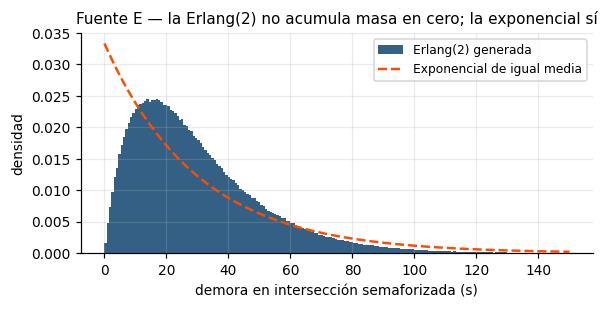

In [14]:
g = gen.Generador(config.SEMILLA)
lam_e = 2.5
e = g.exponenciales(N, lam_e)
er = g.erlang(N, config.ERLANG_K, config.ERLANG_LAMBDA)

ks_e = stats.kstest(e, "expon", args=(0, 1 / lam_e))
ks_r = stats.kstest(er, "gamma", args=(config.ERLANG_K, 0, 1 / config.ERLANG_LAMBDA))

display(pd.DataFrame([
    {"variable": f"Exponencial(λ={lam_e})", "media": e.mean(), "media teórica": 1 / lam_e,
     "varianza": e.var(), "var. teórica": 1 / lam_e**2, "KS D": ks_e.statistic, "KS p": ks_e.pvalue},
    {"variable": f"Erlang(k={config.ERLANG_K}, λ={config.ERLANG_LAMBDA:.4f})",
     "media": er.mean(), "media teórica": config.ERLANG_K / config.ERLANG_LAMBDA,
     "varianza": er.var(), "var. teórica": config.ERLANG_K / config.ERLANG_LAMBDA**2,
     "KS D": ks_r.statistic, "KS p": ks_r.pvalue},
]).set_index("variable").round(4))

assert abs(e.mean() - 1 / lam_e) < 0.01 / lam_e
assert abs(er.mean() - config.ERLANG_MEDIA_S) < 0.2
print(f"\nDemora mediana en intersección: {np.median(er):.1f} s   "
      f"p95: {np.percentile(er, 95):.1f} s")

fig, eje = plt.subplots(figsize=(6, 2.6))
xs = np.linspace(0, 150, 400)
eje.hist(er, bins=200, range=(0, 150), density=True, color=config.NAVY,
         alpha=0.8, label="Erlang(2) generada")
eje.plot(xs, stats.expon.pdf(xs, 0, config.ERLANG_MEDIA_S), color=config.ORANGE,
         lw=1.6, ls="--", label="Exponencial de igual media")
eje.set_xlabel("demora en intersección semaforizada (s)"); eje.set_ylabel("densidad")
eje.legend(fontsize=8)
eje.set_title("Fuente E — la Erlang(2) no acumula masa en cero; la exponencial sí",
              fontsize=10)
plt.show()

## 7. Par 2 de §7 — Poisson homogéneo por dos caminos

- **A, inversa:** acumular $-\ln(1-U)/\lambda$ hasta pasar $T$. Sirve en línea.
- **B, condicionamiento:** sortear $N \sim \text{Poisson}(\lambda T)$ y colocar
  $N$ uniformes ordenadas en $[0,T]$. Necesita $T$ de antemano.

Los dos son exactos, así que la comparación es de costo y de conveniencia. Se
verifica que dan la misma distribución de $N(T)$.

In [15]:
T_PRUEBA, LAM_PRUEBA, REPLICAS = 3.0, 1500.0, 500
media_teorica = LAM_PRUEBA * T_PRUEBA

g = gen.Generador(config.SEMILLA)
conteos = {m: np.array([g.poisson_homogeneo(T_PRUEBA, LAM_PRUEBA, m).size
                        for _ in range(REPLICAS)])
           for m in ("inversa", "condicional")}

# Chi-cuadrado de N(T) contra Poisson(λT), con clases de igual probabilidad
# teórica para que no dependa de dónde se pongan los bordes.
K_CLASES = 10
cortes = stats.poisson.ppf(np.linspace(0, 1, K_CLASES + 1)[1:-1], media_teorica)
bordes_p = np.concatenate([[-np.inf], cortes, [np.inf]])
prob = np.diff(np.concatenate([[0.0], stats.poisson.cdf(cortes, media_teorica), [1.0]]))

filas = []
for m, c in conteos.items():
    obs_c = np.histogram(c, bins=bordes_p)[0]
    chi_c = stats.chisquare(obs_c, prob * REPLICAS)
    filas.append({"método": m, "N medio": c.mean(), "N teórico": media_teorica,
                  "varianza": c.var(ddof=1), "var. teórica": media_teorica,
                  "χ² vs Poisson": chi_c.statistic, "gl": K_CLASES - 1,
                  "p": chi_c.pvalue})
display(pd.DataFrame(filas).set_index("método").round(3))

# Los dos métodos tienen que dar la MISMA distribución de N(T).
mw = stats.mannwhitneyu(conteos["inversa"], conteos["condicional"])
ks2 = stats.ks_2samp(conteos["inversa"], conteos["condicional"])
print(f"\n¿Producen la misma distribución de N(T)?")
print(f"  KS de dos muestras : D = {ks2.statistic:.4f}   p = {ks2.pvalue:.3f}")
print(f"  Mann-Whitney       : p = {mw.pvalue:.3f}")
assert ks2.pvalue > 0.01, "los dos métodos de Poisson no coinciden"

# Los tiempos entre llegadas del método A tienen que ser exponenciales.
t = g.poisson_homogeneo(T_PRUEBA, LAM_PRUEBA, "inversa")
ks_ent = stats.kstest(np.diff(t), "expon", args=(0, 1 / LAM_PRUEBA))
print(f"  tiempos entre llegadas ~ Exp(λ): D = {ks_ent.statistic:.4f}  p = {ks_ent.pvalue:.3f}")
assert np.all(np.diff(t) >= 0) and t.min() >= 0 and t.max() < T_PRUEBA

,N medio,N teórico,varianza,var. teórica,χ² vs Poisson,gl,p
método,,,,,,,
inversa,4500.852,4500.0,4945.048,4500.0,14.371,9,0.110
condicional,4500.536,4500.0,4309.872,4500.0,11.354,9,0.252



¿Producen la misma distribución de N(T)?
  KS de dos muestras : D = 0.0360   p = 0.903
  Mann-Whitney       : p = 0.843
  tiempos entre llegadas ~ Exp(λ): D = 0.0124  p = 0.479


## 8. Fuente A — Poisson no homogéneo por adelgazamiento

Es el generador de llegadas que usa la simulación. La intensidad no es constante:

$$\lambda(t) = \lambda_{\min} + (\lambda_{\max}-\lambda_{\min})\,
\exp\!\left(-\frac{(t-t_{\text{pico}})^2}{2\tau^2}\right)$$

con $t$ en horas desde las 16:00. Se simula un homogéneo de tasa
$\lambda^* = \lambda_{\max}$ y cada candidato se conserva con probabilidad
$\lambda(t)/\lambda^*$.

La eficiencia del adelgazamiento —fracción aceptada— la pide §5.1 y tiene valor
teórico contra el cual contrastarla:

$$\text{eficiencia} = \frac{\int_0^T \lambda(t)\,dt}{\lambda^* T}$$

In [16]:
T = config.HORIZONTE_H
integral, _ = quad(lambda x: float(config.lambda_llegadas(x)), 0, T)
ef_teorica = integral / (config.LAMBDA_COTA * T)

print(f"λ_min = {config.LAMBDA_MIN:.0f} veh/h      λ_max = {config.LAMBDA_MAX:.0f} veh/h")
_h = config.HORA_INICIO + config.T_PICO_H
print(f"t_pico = {config.T_PICO_H} h ({int(_h):02d}:{round(_h % 1 * 60):02d})   τ = {config.TAU_H} h")
print(f"horizonte = {T} h ({config.HORA_INICIO}:00–{config.HORA_INICIO + T:.0f}:00)")
print(f"\n∫λ(t)dt = {integral:.1f} vehículos esperados por réplica")
print(f"eficiencia teórica del adelgazamiento = {ef_teorica:.4f}")

g = gen.Generador(config.SEMILLA)
llegadas, ef = g.poisson_nh(T, config.lambda_llegadas, config.LAMBDA_COTA,
                            devolver_eficiencia=True)
print(f"\nuna réplica: {llegadas.size} llegadas, eficiencia medida = {ef:.4f}")

R = 400
tot, efs = [], []
for _ in range(R):
    ll, e_ = g.poisson_nh(T, config.lambda_llegadas, config.LAMBDA_COTA,
                          devolver_eficiencia=True)
    tot.append(ll.size); efs.append(e_)
tot, efs = np.array(tot), np.array(efs)
ee = tot.std(ddof=1) / np.sqrt(R)
print(f"\nsobre {R} réplicas:")
print(f"  vehículos: media = {tot.mean():.1f} ± {ee:.1f} (e.e.)   contra ∫λ = {integral:.1f}"
      f"   ->  z = {(tot.mean() - integral) / ee:+.2f}")
print(f"  desv. estándar = {tot.std(ddof=1):.1f}   contra √(∫λ) = {np.sqrt(integral):.1f}"
      f"   (un Poisson tiene var = media)")
print(f"  eficiencia = {efs.mean():.4f}   contra la teórica {ef_teorica:.4f}")

assert abs(tot.mean() - integral) < 4 * ee, "el NHPP está sesgado"
assert abs(efs.mean() - ef_teorica) < 0.01

λ_min = 800 veh/h      λ_max = 2300 veh/h
t_pico = 1.5 h (17:30)   τ = 0.75 h
horizonte = 3.0 h (16:00–19:00)

∫λ(t)dt = 5091.6 vehículos esperados por réplica
eficiencia teórica del adelgazamiento = 0.7379

una réplica: 5079 llegadas, eficiencia medida = 0.7402

sobre 400 réplicas:
  vehículos: media = 5084.7 ± 3.7 (e.e.)   contra ∫λ = 5091.6   ->  z = -1.90
  desv. estándar = 73.2   contra √(∫λ) = 71.4   (un Poisson tiene var = media)
  eficiencia = 0.7380   contra la teórica 0.7379


conteos en 12 intervalos sobre 200 réplicas
  X² = 7.55   gl = 12   p = 0.819


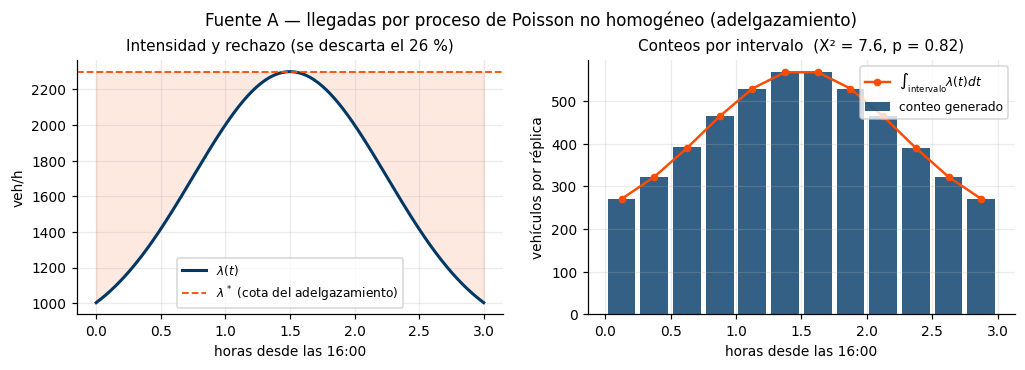

guardada: C:\Users\Virus\OneDrive - UVG\Progra\proyecto-trafico\figuras\03_llegadas_nhpp.png


In [17]:
# §8 pide contrastar los conteos por intervalo contra la integral de λ. El χ²
# de SciPy condiciona en el total, pero aquí el total es aleatorio y los conteos
# son Poisson independientes: el estadístico va con tantos grados de libertad
# como intervalos, sin restar uno.
R_C, K = 200, 12
bordes = np.linspace(0, T, K + 1)
muestra = np.concatenate([g.poisson_nh(T, config.lambda_llegadas, config.LAMBDA_COTA)
                          for _ in range(R_C)])
obs = np.histogram(muestra, bins=bordes)[0]
esp = np.array([quad(lambda x: float(config.lambda_llegadas(x)), bordes[i], bordes[i + 1])[0]
                for i in range(K)]) * R_C

X2 = float(((obs - esp) ** 2 / esp).sum())
p = float(stats.chi2.sf(X2, K))
print(f"conteos en {K} intervalos sobre {R_C} réplicas")
print(f"  X² = {X2:.2f}   gl = {K}   p = {p:.3f}")
assert p > 0.01, "los conteos por intervalo no siguen ∫λ"

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.0))
ts = np.linspace(0, T, 400)
a1.plot(ts, config.lambda_llegadas(ts), color=config.NAVY, lw=2, label=r"$\lambda(t)$")
a1.axhline(config.LAMBDA_COTA, color=config.ORANGE, ls="--", lw=1.2,
           label=r"$\lambda^*$ (cota del adelgazamiento)")
a1.fill_between(ts, config.lambda_llegadas(ts), config.LAMBDA_COTA,
                color=config.ORANGE, alpha=0.12)
a1.set_xlabel("horas desde las 16:00"); a1.set_ylabel("veh/h")
a1.set_title(f"Intensidad y rechazo (se descarta el {100*(1-ef_teorica):.0f} %)", fontsize=10)
a1.legend(fontsize=8)

centros = (bordes[:-1] + bordes[1:]) / 2
a2.bar(centros, obs / R_C, width=T / K * 0.85, color=config.NAVY, alpha=0.8,
       label="conteo generado")
a2.plot(centros, esp / R_C, "o-", color=config.ORANGE, lw=1.6, ms=4,
        label=r"$\int_{\rm intervalo}\lambda(t)dt$")
a2.set_xlabel("horas desde las 16:00"); a2.set_ylabel("vehículos por réplica")
a2.set_title(f"Conteos por intervalo  (X² = {X2:.1f}, p = {p:.2f})", fontsize=10)
a2.legend(fontsize=8)
fig.suptitle("Fuente A — llegadas por proceso de Poisson no homogéneo (adelgazamiento)",
             y=1.03, fontsize=11)
for ext in ("png", "pdf"):
    fig.savefig(config.FIGURAS / f"03_llegadas_nhpp.{ext}")
plt.show()
print(f"guardada: {config.FIGURAS / '03_llegadas_nhpp.png'}")

## 9. Fuente B — origen y destino

Transformada inversa discreta sobre la acumulada. Con pocas categorías es exacta
y cuesta un uniforme.

In [18]:
g = gen.Generador(config.SEMILLA)
claves = list(config.ZONAS)
pesos = np.array([config.ZONAS[k]["peso"] for k in claves])
idx = g.categorica(500_000, pesos)
frec = np.bincount(idx, minlength=len(claves)) / idx.size

chi = stats.chisquare(np.bincount(idx, minlength=len(claves)), pesos * idx.size)
display(pd.DataFrame({"zona": claves, "peso declarado": pesos,
                      "frecuencia generada": frec,
                      "error": frec - pesos}).set_index("zona").round(5))
print(f"χ² = {chi.statistic:.3f}   p = {chi.pvalue:.3f}")
assert np.allclose(frec, pesos, atol=0.003)

,peso declarado,frecuencia generada,error
zona,,,
z10,0.40,0.40003,0.00003
z15,0.35,0.35079,0.00079
z16,0.25,0.24918,-0.00082


χ² = 2.237   p = 0.327


## 10. Criterio 1 — costo computacional

Nanosegundos por variable. `timeit` con 10⁶ variables y 7 repeticiones; se
reporta la mediana, que aguanta que el sistema operativo se lleve el procesador
en medio de una corrida.

In [19]:
# Mediana de `repeticiones` corridas, en nanosegundos por variable.
def ns_por_variable(fabricar, n=N_TIEMPO, repeticiones=REPETICIONES):
    tiempos = timeit.repeat(fabricar, number=1, repeat=repeticiones)
    return np.median(tiempos) / n * 1e9

tareas = []
for f in gen.FUENTES:
    g_ = gen.Generador(config.SEMILLA, f)
    tareas.append((f"uniforme · {f}", "uniforme", f, lambda g_=g_: g_.uniformes(N_TIEMPO)))
for f in ("pcg64", "lcg"):
    for m in gen.METODOS_NORMAL:
        g_ = gen.Generador(config.SEMILLA, f, m)
        tareas.append((f"normal {m} · {f}", "normal", f, lambda g_=g_, m=m: g_.normales(N_TIEMPO, m)))
g_ = gen.Generador(config.SEMILLA)
tareas.append(("exponencial · pcg64", "exponencial", "pcg64", lambda g_=g_: g_.exponenciales(N_TIEMPO, 1.0)))
g_ = gen.Generador(config.SEMILLA)
tareas.append(("erlang(2) · pcg64", "erlang", "pcg64", lambda g_=g_: g_.erlang(N_TIEMPO)))
g_ = gen.Generador(config.SEMILLA)
tareas.append(("lognormal · pcg64", "lognormal", "pcg64", lambda g_=g_: g_.lognormales(N_TIEMPO)))

filas = []
for etiqueta, familia, f, fn in tareas:
    filas.append({"tarea": etiqueta, "familia": familia, "fuente": f,
                  "ns/variable": ns_por_variable(fn)})
tiempos = pd.DataFrame(filas)
display(tiempos.set_index("tarea").round(2))

,familia,fuente,ns/variable
tarea,,,
uniforme · pcg64,uniforme,pcg64,3.34
uniforme · lcg,uniforme,lcg,12.59
uniforme · randu,uniforme,randu,11.93
normal polar · pcg64,normal,pcg64,59.61
normal rechazo · pcg64,normal,pcg64,68.16
normal polar · lcg,normal,lcg,66.50
normal rechazo · lcg,normal,lcg,97.06
exponencial · pcg64,exponencial,pcg64,22.38
erlang(2) · pcg64,erlang,pcg64,54.55


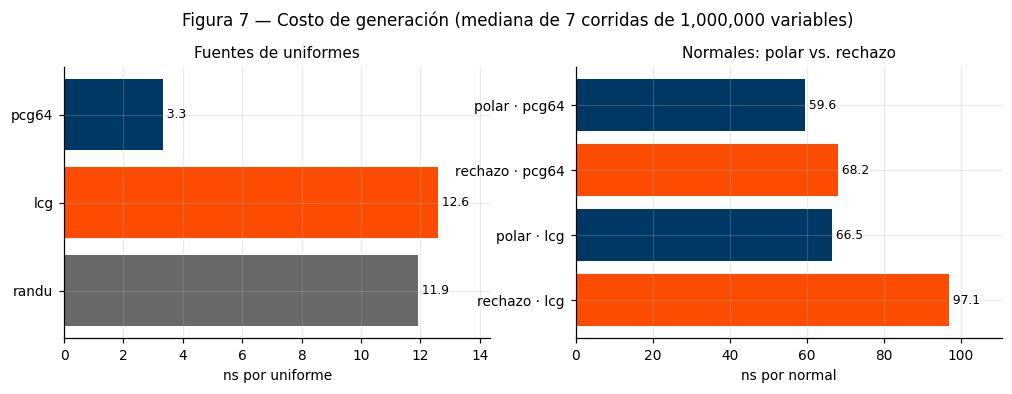

guardada: C:\Users\Virus\OneDrive - UVG\Progra\proyecto-trafico\figuras\07_costo_generacion.png


In [20]:
# ---- Figura 7 de §14 ----
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.2))

u_t = tiempos[tiempos.familia == "uniforme"].set_index("fuente")["ns/variable"]
a1.barh(u_t.index, u_t.values, color=[config.NAVY, config.ORANGE, config.GREY])
for i, v in enumerate(u_t.values):
    a1.text(v, i, f" {v:.1f}", va="center", fontsize=8)
a1.margins(x=0.14)
a1.set_xlabel("ns por uniforme"); a1.set_title("Fuentes de uniformes", fontsize=10)
a1.invert_yaxis()

n_t = tiempos[tiempos.familia == "normal"].copy()
n_t["etiqueta"] = n_t.tarea.str.replace("normal ", "", regex=False)
a2.barh(n_t["etiqueta"], n_t["ns/variable"],
        color=[config.NAVY if "polar" in e else config.ORANGE for e in n_t["etiqueta"]])
for i, v in enumerate(n_t["ns/variable"].values):
    a2.text(v, i, f" {v:.1f}", va="center", fontsize=8)
a2.margins(x=0.14)
a2.set_xlabel("ns por normal"); a2.set_title("Normales: polar vs. rechazo", fontsize=10)
a2.invert_yaxis()

fig.suptitle(f"Figura 7 — Costo de generación (mediana de {REPETICIONES} corridas de "
             f"{N_TIEMPO:,} variables)", y=1.04, fontsize=11)
for ext in ("png", "pdf"):
    fig.savefig(config.FIGURAS / f"07_costo_generacion.{ext}")
plt.show()
print(f"guardada: {config.FIGURAS / '07_costo_generacion.png'}")

## 11. Criterio 2 — eficiencia del rechazo

Uniformes consumidos por variable aceptada, contra la teoría:

| Método | Teoría | De dónde sale |
|---|---|---|
| Polar | $4/\pi \approx 1.273$ | 2 por intento, aceptación $\pi/4$, 2 normales por acierto |
| Rechazo | $2c+1 \approx 3.631$ | 2 por intento, aceptación $1/c$, más 1 para el signo |

El generador lleva un contador interno, así que el número se lee en vez de
estimarse. El exceso viene del tamaño de las tandas y decrece como $1/\sqrt{n}$.

In [21]:
filas = []
for n in (10_000, 100_000, 1_000_000):
    for metodo in gen.METODOS_NORMAL:
        g_ = gen.Generador(config.SEMILLA, "pcg64", metodo)
        g_.normales(n)
        teo = gen.TEORICO_UNIFORMES_POR_NORMAL[metodo]
        filas.append({"n": n, "método": metodo,
                      "uniformes/normal": g_.uniformes_consumidos / n,
                      "teórico": teo,
                      "exceso %": 100 * (g_.uniformes_consumidos / n - teo) / teo})
eficiencia = pd.DataFrame(filas).pivot_table(
    index="n", columns="método", values=["uniformes/normal", "exceso %"])
display(eficiencia.round(4))

for metodo in gen.METODOS_NORMAL:
    g_ = gen.Generador(config.SEMILLA, "pcg64", metodo)
    g_.normales(1_000_000)
    medido = g_.uniformes_consumidos / 1_000_000
    teo = gen.TEORICO_UNIFORMES_POR_NORMAL[metodo]
    assert abs(medido - teo) / teo < 0.01, f"{metodo}: {medido:.4f} vs {teo:.4f}"
    print(f"{metodo:8s}  medido {medido:.4f}   teórico {teo:.4f}   "
          f"desviación {100*abs(medido-teo)/teo:.2f} %  ✓")

print(f"\nEl polar consume {gen.TEORICO_UNIFORMES_POR_NORMAL['rechazo'] / gen.TEORICO_UNIFORMES_POR_NORMAL['polar']:.2f}× "
      "menos uniformes que el rechazo.")

exceso %         uniformes/normal        
método     polar rechazo            polar rechazo
n                                                
10000     2.0389  1.7963           1.2992  3.6962
100000    0.6284  0.4933           1.2812  3.6489
1000000   0.1972  0.1434           1.2758  3.6362

polar     medido 1.2757   teórico 1.2732   desviación 0.20 %  ✓
rechazo   medido 3.6362   teórico 3.6310   desviación 0.14 %  ✓

El polar consume 2.85× menos uniformes que el rechazo.


## 12. Criterio 6 — facilidad de implementación

Líneas efectivas (sin blancos, comentarios ni documentación), dependencias y
casos borde. Es el más subjetivo de los seis, así que lleva una cuenta objetiva
al lado.

In [22]:
facilidad = pd.DataFrame([
    {"método": "polar", "líneas": gen.lineas_de_codigo(gen.Generador._normales_polar),
     "dependencias": "ninguna",
     "casos borde": "S = 0 (divide); caché de la normal sobrante cuando n es impar"},
    {"método": "rechazo", "líneas": gen.lineas_de_codigo(gen.Generador._normales_rechazo),
     "dependencias": "ninguna",
     "casos borde": "U = 0 en el logaritmo; un uniforme extra para el signo"},
    {"método": "LCG", "líneas": gen.lineas_de_codigo(gen.FuenteLCG.enteros),
     "dependencias": "ninguna",
     "casos borde": "desborde de uint64; semilla par degenera si c = 0; salto adelante para vectorizar"},
    {"método": "PCG64", "líneas": gen.lineas_de_codigo(gen.FuentePCG64.uniformes),
     "dependencias": "NumPy", "casos borde": "ninguno"},
    {"método": "Poisson inversa", "líneas": gen.lineas_de_codigo(gen.Generador._poisson_inversa),
     "dependencias": "ninguna", "casos borde": "la tanda puede quedarse corta y hay que continuarla"},
    {"método": "Poisson condicional", "líneas": gen.lineas_de_codigo(gen.Generador._poisson_condicional)
     + gen.lineas_de_codigo(gen.Generador.poisson_conteo),
     "dependencias": "SciPy", "casos borde": "e^(−λT) desborda por debajo con λT ≈ 6 900"},
    {"método": "NHPP adelgazamiento", "líneas": gen.lineas_de_codigo(gen.Generador.poisson_nh),
     "dependencias": "ninguna", "casos borde": "hay que conocer una cota λ* válida"},
]).set_index("método")
display(facilidad)

,líneas,dependencias,casos borde
método,,,
polar,20,ninguna,S = 0 (divide); caché de la normal sobrante cu...
rechazo,19,ninguna,U = 0 en el logaritmo; un uniforme extra para ...
LCG,22,ninguna,desborde de uint64; semilla par degenera si c ...
PCG64,2,NumPy,ninguno
Poisson inversa,14,ninguna,la tanda puede quedarse corta y hay que contin...
Poisson condicional,7,SciPy,e^(−λT) desborda por debajo con λT ≈ 6 900
NHPP adelgazamiento,13,ninguna,hay que conocer una cota λ* válida


## 13. Resumen

**Par 1, normales.** Los dos métodos son exactos y no se distinguen en calidad:
mismo KS, misma cola. Donde sí se separan es en costo, y ahí gana el polar, con
menos tiempo y 2.85× menos uniformes. El proyecto usa el polar y deja el
rechazo documentado como competidor.

| Criterio | Polar | Rechazo | Gana |
|---|---|---|---|
| 1 · costo | ver figura 7 | ver figura 7 | polar |
| 2 · uniformes/variable | 1.273 | 3.631 | polar, por 2.85× |
| 3 · calidad | KS no rechaza | KS no rechaza | empate |
| 4 · cola a 3σ | razón ≈ 1 | razón ≈ 1 | empate |
| 6 · implementación | + la caché del sobrante | + el uniforme del signo | empate |

**Par 2, Poisson.** Ambos exactos y con la misma distribución de $N(T)$. La
inversa sirve en línea y es la que el adelgazamiento necesita; el
condicionamiento pide $T$ de antemano y, con $\lambda T \approx 6\,900$, obliga
a evaluar la inversa de la Poisson con SciPy porque la recursión clásica
desborda. Se usa la inversa.

**Par 3, uniformes.** Los tres pasan las pruebas de una dimensión y RANDU está
roto igual; la prueba que lo demuestra es tridimensional. Se usa PCG64 para
producir resultados, el LCG propio como implementación verificada y RANDU solo
como control.

Falta el criterio 5: correr la simulación completa con cada generador y ver si
el Δ% se mueve más allá del error Monte Carlo. Es del notebook 04, y la interfaz
ya está lista.

In [23]:
derivado = {
    "semilla": config.SEMILLA,
    "n_muestra": N,
    "parametros": {
        "lambda_min": config.LAMBDA_MIN, "lambda_max": config.LAMBDA_MAX,
        "t_pico_h": config.T_PICO_H, "tau_h": config.TAU_H,
        "horizonte_h": config.HORIZONTE_H,
        "integral_lambda": float(integral),
        "eficiencia_adelgazamiento_teorica": float(ef_teorica),
        "eficiencia_adelgazamiento_medida": float(efs.mean()),
        "logn_mu": config.LOGN_MU, "logn_sigma": config.LOGN_SIGMA,
        "erlang_k": config.ERLANG_K, "erlang_lambda": config.ERLANG_LAMBDA,
    },
    "pruebas_uniformes": pruebas_unif.round(6).to_dict("index"),
    "normales": normales_res.round(6).to_dict("index"),
    "uniformes_por_normal": {
        m: {"medido": float(consumo[m]),
            "teorico": float(gen.TEORICO_UNIFORMES_POR_NORMAL[m])}
        for m in gen.METODOS_NORMAL},
    "cola_3sigma": {m: gen.razon_cola(z, 3.0) for m, z in Z.items()},
    "tiempos_ns_por_variable": tiempos.set_index("tarea")["ns/variable"].round(3).to_dict(),
    "randu_planos": 15,
    "figuras": ["05_randu_planos", "06_qq_normales", "07_costo_generacion",
                "03_llegadas_nhpp"],
}

destino = config.DERIVADOS / "03_generadores.json"
destino.write_text(json.dumps(derivado, ensure_ascii=False, indent=2), encoding="utf-8")
print(f"guardado: {destino}")

guardado: C:\Users\Virus\OneDrive - UVG\Progra\proyecto-trafico\data\derivados\03_generadores.json


---

## Qué queda listo

- `src/generadores.py` con las seis fuentes de §4, tres fuentes de uniformes y
  dos métodos para normales, todo detrás de una sola interfaz.
- Las pruebas de §8 corriendo como aserciones.
- Los criterios 1, 2, 3, 4 y 6 de §7 medidos.
- Figuras 5, 6 y 7 de §14, más la de las llegadas.
- `data/derivados/03_generadores.json` con las cifras, para no copiarlas a mano
  al informe.

**Sigue:** `04_simulacion.ipynb` (pista C). Lo que este notebook le entrega:

```python
from generadores import Generador

g = Generador(config.SEMILLA + replica, fuente_nombre="pcg64", metodo_normal="polar")
llegadas = g.poisson_nh(config.HORIZONTE_H, config.lambda_llegadas, config.LAMBDA_COTA)
s        = g.lognormales(n, config.LOGN_MU, config.LOGN_SIGMA)   # fuente D
demoras  = g.erlang(n)                                            # fuente E
od       = g.categorica(n, pesos)                                 # fuente B
cap      = g.normales_truncadas(n, mu, sigma, bajo=..., alto=...)  # fuente F
```

Para los números comunes de §5.6, la réplica *r* del escenario cerrado usa la
misma semilla que la del base y el generador se recorre en el mismo orden: entre
escenarios solo cambia la red, nunca la secuencia.

Para el criterio 5 basta cambiar `fuente_nombre` a `"lcg"` o `"randu"` y volver
a correr, sin tocar ninguna otra línea.